In [44]:
#load relevant packages

import pandas as pd
import ast
import pysam
from Bio import SeqIO
import glob
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from histogramplotter import *
import os
from dnds import dnds, pnps
# print(dnds.__file__)

from utils import *
import argparse

In [2]:
# set up directories to which to point

experiment_id = 'jh_005'
fasta_name = 'pjh3_nbonly'

mutation_df_paths = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/*'

csv_files = glob.glob(os.path.join(mutation_df_paths, f"*scores*.csv"))
print(csv_files)



['../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_005/neutral_drift_library/libonly/library_scores_jh_005.csv', '../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_005/neutral_drift_library/wtspike/library_scores_jh_005.csv']


In [3]:
# start extracting dna and amino acid sequences from each dataframe

rep1_df = pd.read_csv(csv_files[0], index_col=0)
rep2_df = pd.read_csv(csv_files[1], index_col=0)

print(len(rep1_df))
print(len(rep2_df))

rep1_dnaseq = rep1_df['dna_sequence']
rep2_dnaseq = rep2_df['dna_sequence']

print(rep1_dnaseq[:6])
# rep1_dnaseq = rep1_dnaseq.apply(ast.literal_eval)
# rep2_dnaseqtrunc1 = rep2_dnaseq[:1600].apply(ast.literal_eval)
# rep2_dnaseqtrunc2 = rep2_dnaseq[1601:1620].apply(ast.literal_eval)

# rep1_dnaseq_flat = rep1_dnaseq['dna_sequence'].explode()
# rep2_dnaseq_flat = rep2_dnaseqtrunc1['dna_sequence'].explode()

# rep1_dnaseq_flat = [item for sublist in rep1_dnaseq for item in sublist]
# rep2_dnaseq_flat = [item for sublist in rep2_dnaseq for item in sublist]
# print(rep2_dnaseq_flat[:5])
rep1_df.head()

733
1616
0    ['CAGATCCAACTGGCCGAGAGCGGTGGGGGACTGGTGCAGCCAGG...
1    ['CAGATCCAACTGGCCGAGAGCGGTGGGGGACTGGTGCAGTCAGG...
2    ['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...
3    ['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...
4    ['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...
5    ['CAGGTCCAACTGGCCGAGAGCGATGGGGGACTGGTGCAGCCAGG...
Name: dna_sequence, dtype: object


,aa_sequence,dna_sequence,dna_mutations,aa_mutations,number_dna_mutations,number_aa_mutations,bin_1,bin_2,bin_3,normalized_score_lib,normalized_score_spike,predicted_category
0,QIQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPDQGLE...,['CAGATCCAACTGGCCGAGAGCGGTGGGGGACTGGTGCAGCCAGG...,"[""['G4A', 'T14C', 'A54G', 'T87A', 'G125A', 'T1...","['V2I', 'V5A', 'G42D', 'A60T', 'S70I', 'A91T']",[11],6,0.000000,0.590514,0.409486,0.704743,0.704743,WT-like
1,QIQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGATCCAACTGGCCGAGAGCGGTGGGGGACTGGTGCAGTCAGG...,"[""['G4A', 'T14C', 'C40T', 'T87A', 'G114A', 'G1...","['V2I', 'V5A', 'P14S', 'A49T', 'T115S']",[11],5,0.000000,0.602258,0.397742,0.698871,0.698871,WT-like
2,QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23C', 'T87A', 'C203T', 'A343G']"",...","['V5A', 'G8A', 'T68M', 'T115A']","[5, 6, 6, 7, 6, 7]",4,0.000000,0.011875,0.988125,0.994063,0.994063,WT-like
3,QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23C', 'T87A', 'C203T']"", ""['T14C'...","['V5A', 'G8A', 'T68M']","[4, 6, 6, 7, 7, 10, 6]",3,0.013074,0.051447,0.935479,0.961203,0.961203,WT-like
4,QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23C', 'T87A', 'C201T', 'C210T', '...","['V5A', 'G8A']","[7, 7, 5, 9]",2,0.000000,0.053415,0.946585,0.973292,0.973292,WT-like


In [4]:
rep1_aaseq = rep1_df['aa_sequence']
rep2_aaseq = rep2_df['aa_sequence']

print(rep1_aaseq[:3])
print(len(rep1_aaseq))
print(rep2_aaseq[135:145])
print(len(rep2_aaseq))

# print(rep2_aaseq.index)
# print(rep2_aaseq.iloc[140])

0    QIQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPDQGLE...
1    QIQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
2    QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
Name: aa_sequence, dtype: object
733
285    QVQLTESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
183    QVQLAESGGGLVQPGGSLRLSCAVSGRNVPMLSLGWFRQAPGQALE...
73     QVQLAESGGGLVQPGDSLRLSCAASGSNIPMLSLGWFRQAPGQGLE...
110    QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQDLE...
321    QVQLVESGRGLIQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
282    QVQLTESGGGLVQPGDSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
260    QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
103    QVQLAESGGGLVQPGGSLRLSCAASGRNVPILSLGWFRQAPGQGLE...
147    QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
159    QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
Name: aa_sequence, dtype: object
1616


In [5]:
# lets try to compare which sequences are common between the reps

set1_aaseq = set(rep1_aaseq)
set2_aaseq = set(rep2_aaseq)

common_seqs = set1_aaseq.intersection(set2_aaseq)

common_seqs_list = list(common_seqs)

# print(common_seqs_list[:6])
# print(len(common_seqs_list))

very interesting that only 139 sequences are observed in common between both reps... likely cause of low sequence count

In [6]:
# lets learn more about the sequences that are not common between the sequences

set1_unique = set1_aaseq - set2_aaseq
set2_unique = set2_aaseq - set1_aaseq

rep1_unique = rep1_aaseq[rep1_aaseq.isin(set1_unique)]
rep2_unique = rep2_aaseq[rep2_aaseq.isin(set2_unique)]

print(rep1_unique[:3])
print(len(rep1_unique))
print(rep2_unique[:3])
print(len(rep2_unique))

0    QIQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPDQGLE...
1    QIQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
5    QVQLAESDGGLVQPGGSLCLSCAASGRNVPMLSLGWFRQAPGQGLE...
Name: aa_sequence, dtype: object
594
13    QVQLAESDGGLVQPGGSLCLSCAASGRNVPMLSLGWFRQAPGQGLE...
34    QVQLAESDGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAQGQGLE...
72    QVQLAESGGGLVQPGDSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...
Name: aa_sequence, dtype: object
1477


In [7]:
ref_fasta_path = f'../../minibinders_orthorep_data/ngs_raw/{experiment_id}/references/{fasta_name}.fasta'
ref_fasta = SeqIO.read(ref_fasta_path, "fasta")
parent_dna_seq = ref_fasta.seq
parent_dna_id = ref_fasta.id

parent_aa_seq = translate_sequence(parent_dna_seq)

print(parent_aa_seq)
print(parent_aa_seq[28:31])

# capture wild type score from dataframes

wt_score = rep1_df[rep1_df['aa_sequence'] == parent_aa_seq]['normalized_score_lib']
print(wt_score.values[0])

QVQLVESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS
VPM
0.90923458297808


In [8]:
# # lets do an example finder of a all sequences one amino acid away
# hamming_pairwise_aa = []
# for aaseq in combinations(rep1_aaseq[:5], 2):
#     hamming_pairwise_aa.append(hamming_distance(aaseq[0],aaseq[1]))

# print(hamming_pairwise_aa)


In [9]:
hamming_pairwise_aa = []

singlemuts = {}
for i in range(len(rep1_aaseq)):
    aaseq = rep1_aaseq.iloc[i]
    singlemutlist = []
    # print(aaseq)
    for j in range(i+1, len(rep1_aaseq)):
        seqcomp = rep1_aaseq.iloc[j]
        if seqcomp != aaseq:
            hamming_pairwise_aa.append(hamming_distance(aaseq, seqcomp))
        if hamming_pairwise_aa[-1] == 1:
            singlemutlist.append(seqcomp)
            singlemuts[aaseq] = singlemutlist
# print(len(hamming_pairwise_aa))
# print(hamming_pairwise_aa.count(1))
# print(list(singlemuts.values())[:10])
print(len(list(singlemuts.keys())))
# print(singlemuts)

179


In [10]:
# comprehensive list of pairs of single mutants organized by point mutation

mutrec = []

for sequence in list(singlemuts.keys()):
    seqdist = hamming_distance(sequence, parent_aa_seq)
    for variant in list(singlemuts[sequence]):
        vardist = hamming_distance(variant, parent_aa_seq)
        scores = [rep1_df[rep1_df['aa_sequence'] == sequence]['normalized_score_lib'].values[0], rep1_df[rep1_df['aa_sequence'] == variant]['normalized_score_lib'].values[0]] 
        dist = seqdist if seqdist<vardist else vardist
        if seqdist<=vardist:
            dscore = scores[1] - scores[0]
            for j, (aa1, aa2) in enumerate(zip(sequence, variant)):
                if aa1 != aa2:
                    pointmut = str(aa1+str(j+1)+aa2)
        else:
            dscore = scores[0] - scores[1]
            for j, (aa1, aa2) in enumerate(zip(sequence, variant)):
                if aa1 != aa2:
                    pointmut = str(aa2+str(j+1)+aa1) #flips reference and mutation at position
                    
        mutrec.append({
            "sequence1": sequence,
            "sequence2": variant,
            "point mutation": pointmut,
            "wild type distance": dist,
            "score1": scores[0],
            "score2": scores[1],
            "delta score": dscore})

mutrec_df = pd.DataFrame(mutrec)

print(parent_aa_seq)

# print(mutrec_df)
print(mutrec_df[mutrec_df['point mutation'] == 'P30S'])

# group by point mutation

mut_dict = {}
noref_dict = {}

for mutation in mutrec_df['point mutation']:
    position = int(mutation[1:-1])-1
    # print(parent_aa_seq[position])
    if mutation[0] == parent_aa_seq[position]:
        mut_dict[mutation] = list(mutrec_df[mutrec_df['point mutation'] == mutation]['delta score'].values)
    else:
        noref_dict[mutation] = list(mutrec_df[mutrec_df['point mutation'] == mutation]['delta score'].values)

print(noref_dict)

QVQLVESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS
                                             sequence1  \
18   QVQLAESDGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
60   QVQLAESGGGLVQPGDSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
77   QVQLAESGGGLVQPGGSLRLSCAASGKNVPMLSLGWFRQAPGQGLE...   
148  QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
151  QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
190  QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
217  QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
269  QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
305  QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
350  QVQLVESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   

                                             sequence2 point mutation  \
18   QVQLAESDGGLVQPGGSLRLSCAASGRNVSMLSLGWFRQAPGQGLE...           P30S   
60   QVQLAESGGGLVQPGDSLRLSCAASGRNVSMLSLGWFRQAPGQGLE...           P30S   
77   QVQLAESGGGLVQPGG

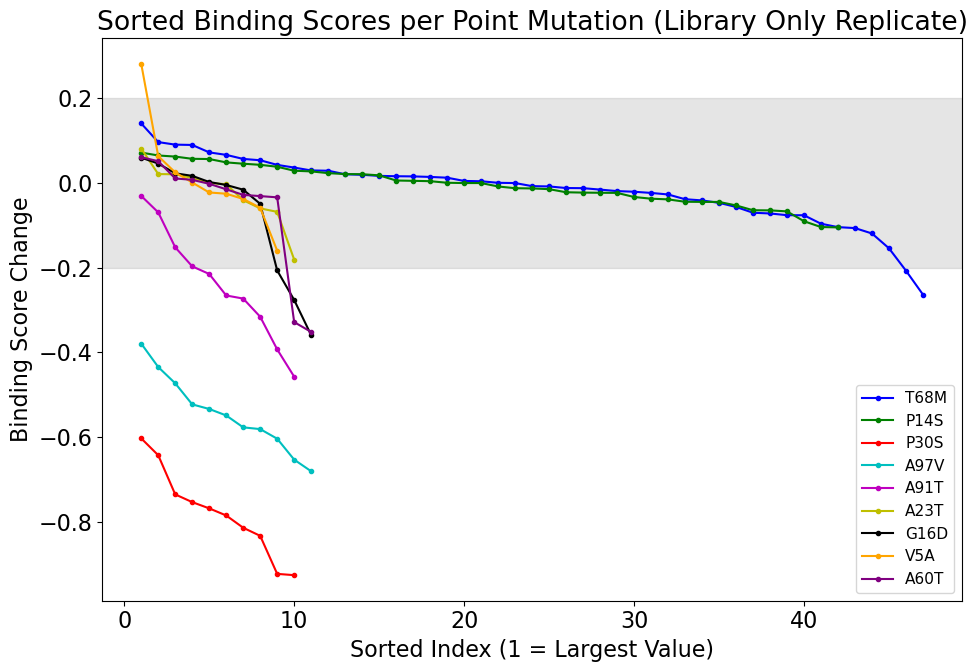

In [65]:
# now let's graph an ordered set of these point mutations and list scores

sorted_mut_dict = {k: sorted(v, reverse=True) for k, v in mut_dict.items()}
# print(sorted_mut_dict)

plt.figure(figsize=(10, 7))

min_examples = 9

for label, values in sorted_mut_dict.items():
    # X values: indices (1, 2, 3, ..., length of list)
    x = range(1, len(values)+1)
    if len(x)>=min_examples:
        plt.plot(x, values, marker='o', markersize=3, label=label)

plt.axhspan(-0.2, 0.2, color='gray', alpha=0.2)
plt.xlabel('Sorted Index (1 = Largest Value)')
plt.ylabel('Binding Score Change')
plt.title('Sorted Binding Scores per Point Mutation (Library Only Replicate)')
plt.legend(fontsize=11,loc='lower right')
plt.tight_layout()
plt.show()


In [12]:
# score comparisons of single mutants (initial visual inspection looked very different)
# also need to identify the point mutation responsible

hotspotmut = []
neutralmut = []


for ref in list(singlemuts.keys()):
    for var in list(singlemuts[ref]):
        # print(hamming_distance(ref,var))
        scores = [rep1_df[rep1_df['aa_sequence'] == ref]['normalized_score_lib'].values[0], rep1_df[rep1_df['aa_sequence'] == var]['normalized_score_lib'].values[0]]
        scoredif = abs(scores[0]-scores[1])
        if scoredif > 0.7:
            # print(f"sequence {ref} with score {scores[0]} has single mutant {var} with score {scores[1]}")
            for i, (aa1, aa2) in enumerate(zip(ref, var)):
                if aa1 != aa2:
                    pointmut = (i+1, aa1, aa2)
                    hotspotmut.append(pointmut)
                    # print(f"point mutation is {aa1}{i+1}{aa2}")
        if scoredif < 0.02:
            print(f"sequence {ref} with score {scores[0]} has single mutant {var} with score {scores[1]}")
            for i, (aa1, aa2) in enumerate(zip(ref, var)):
                if aa1 != aa2:
                    pointmut = (i+1, aa1, aa2)
                    neutralmut.append(pointmut)
                    # print(f"point mutation is {aa1}{i+1}{aa2}")

hotspotmut_df = pd.DataFrame(hotspotmut, columns = ['pos', 'aa1', 'aa2'])
neutralmut_df = pd.DataFrame(neutralmut, columns = ['pos', 'aa1', 'aa2'])


print(hotspotmut_df[hotspotmut_df['pos'] == 30])
# print(len(hotspotmut))
print(neutralmut_df[neutralmut_df['pos'] == 30])
# print(len(neutralmut))


sequence QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGALVTVS with score 0.9940626600460978 has single mutant QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGALVTVS with score 1.0
sequence QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.9612027535204236 has single mutant QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.9732923725970292
sequence QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.9612027535204236 has single mutant QVQLAESDGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.946074444012374
sequence QVQLAESAGGLVQPGGSLRL

In [13]:
# repeat analysis for rep2

hamming_pairwise_aa2 = []

singlemuts2 = {}

for i in range(len(rep2_aaseq)):
    aaseq = rep2_aaseq.iloc[i]
    singlemutlist2 = []
    # print(aaseq)
    for j in range(i+1, len(rep2_aaseq)):
        seqcomp = rep2_aaseq.iloc[j]
        if seqcomp != aaseq:
            hamming_pairwise_aa2.append(hamming_distance(aaseq, seqcomp))
        if hamming_pairwise_aa2[-1] == 1:
            singlemutlist2.append(seqcomp)
            singlemuts2[aaseq] = singlemutlist2
# print(len(hamming_pairwise_aa))
# print(hamming_pairwise_aa.count(1))
print(list(singlemuts2.values())[:10])
print(len(list(singlemuts2.keys())))

[['QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS', 'QVQLAESAGGLVQPGGSLRLSCAASGRNVSMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGALVTVS'], ['QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS', 'QVQLAESDGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS'], ['QVQLAESDGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLVRNWYTYWGQGTLVTVS', 'QVQLAESDGGLVQPGGSLCLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEDKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLVRNWYTYWGQGTLVTVS'], ['QVQLAESDGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS', 'QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS', 

In [33]:
# comprehensive list of pairs of single mutants organized by point mutation (wt spike library)

mutrec2 = []

for sequence in list(singlemuts2.keys()):
    seqdist = hamming_distance(sequence, parent_aa_seq)
    for variant in list(singlemuts2[sequence]):
        vardist = hamming_distance(variant, parent_aa_seq)
        scores = [rep2_df[rep2_df['aa_sequence'] == sequence]['normalized_score_lib'].values[0], rep2_df[rep2_df['aa_sequence'] == variant]['normalized_score_lib'].values[0]] 
        dist = seqdist if seqdist<vardist else vardist
        if seqdist<=vardist:
            dscore = scores[1] - scores[0]
            for j, (aa1, aa2) in enumerate(zip(sequence, variant)):
                if aa1 != aa2:
                    pointmut = str(aa1+str(j+1)+aa2)
        else:
            dscore = scores[0] - scores[1]
            for j, (aa1, aa2) in enumerate(zip(sequence, variant)):
                if aa1 != aa2:
                    pointmut = str(aa2+str(j+1)+aa1) #flips reference and mutation at position
                    
        mutrec2.append({
            "sequence1": sequence,
            "sequence2": variant,
            "point mutation": pointmut,
            "wild type distance": dist,
            "score1": scores[0],
            "score2": scores[1],
            "delta score": dscore})

mutrec_df2 = pd.DataFrame(mutrec2)

print(parent_aa_seq)

# print(mutrec_df)
print(mutrec_df2[mutrec_df2['point mutation'] == 'P30S'])

# group by point mutation

mut_dict2 = {}
noref_dict2 = {}

for mutation in mutrec_df2['point mutation']:
    position = int(mutation[1:-1])-1
    # print(parent_aa_seq[position])
    if mutation[0] == parent_aa_seq[position]:
        mut_dict2[mutation] = list(mutrec_df2[mutrec_df2['point mutation'] == mutation]['delta score'].values)
    else:
        noref_dict2[mutation] = list(mutrec_df2[mutrec_df2['point mutation'] == mutation]['delta score'].values)

print(noref_dict2)

QVQLVESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS
                                             sequence1  \
1    QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
22   QVQLAESDGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
34   QVQLAESGGGLVQPGDSLCLSCAASGRNVPMLSLGWFRQAPGQDLE...   
61   QVQLAESGGGLVQPGGSLRLSCAASGKNVPMLSLGWFRQAPGQGLE...   
68   QVQLAESGGGLVQPGGSLRLSCAASGRNIPMLSLGWFRQAPGQGLE...   
77   QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQDLE...   
80   QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
105  QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
154  QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
165  QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
177  QVQLTESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
213  QVQLAESGGGLVQSGGSLRLSCDASGRNVPMLSLGWFRQAPGQGLE...   
249  QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
275  QVQLAESDGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...   
277  QVQL

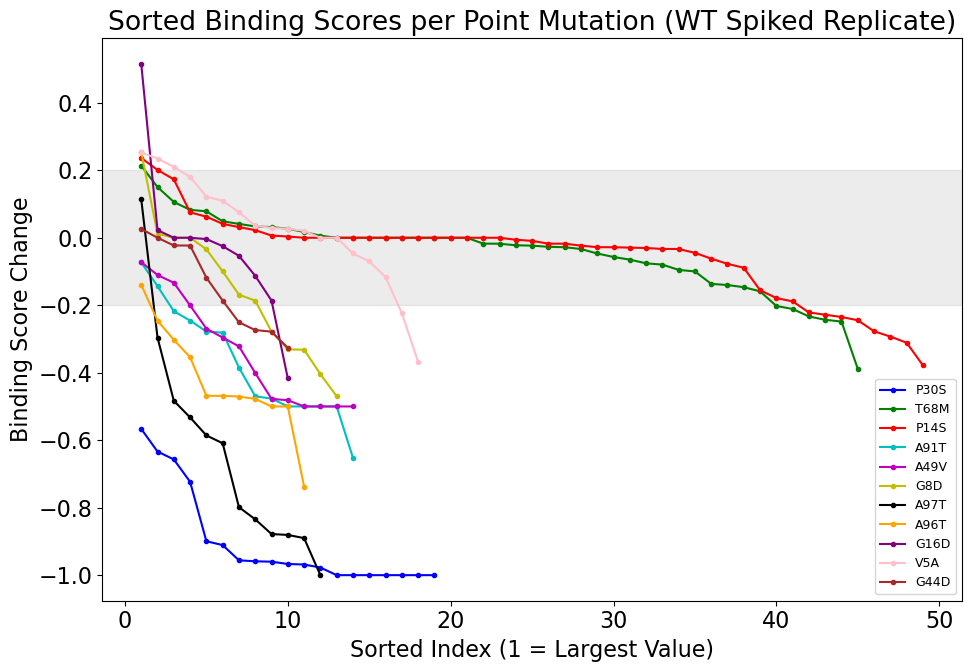

In [52]:
# now let's graph an ordered set of these point mutations and list scores

sorted_mut_dict2 = {k: sorted(v, reverse=True) for k, v in mut_dict2.items()}
# print(sorted_mut_dict)
color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'pink', 'brown', 'olive', 'navy', 'teal']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=color_list)

plt.figure(figsize=(10, 7))

min_examples = 10

for label, values in sorted_mut_dict2.items():
    # X values: indices (1, 2, 3, ..., length of list)
    x = range(1, len(values)+1)
    if len(x)>=min_examples:
        plt.plot(x, values, marker='o', markersize=3, label=label)

plt.axhspan(-0.2, 0.2, color='gray', alpha=0.15)
plt.xlabel('Sorted Index (1 = Largest Value)')
plt.ylabel('Binding Score Change')
plt.title('Sorted Binding Scores per Point Mutation (WT Spiked Replicate)')
plt.legend(fontsize=9,loc='lower right')
plt.tight_layout()
plt.show()


In [91]:
# try graphing the above as a "ridge" plot

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

min_contexts = 10
# Create the data
ridgedata = []
for key, values in sorted_mut_dict2.items():
    if len(list(values)) >= min_contexts:
        for v in values:
            ridgedata.append({"mutation": key, "dscore": v})

ridgedata_df = pd.DataFrame(ridgedata)

order = (
    ridgedata_df.groupby("mutation")["dscore"]
    .median()
    .sort_values(ascending=False)
    .index
)

ridgedata_df.head()

,mutation,dscore
0,P30S,-0.566572
1,P30S,-0.633710
2,P30S,-0.656914
3,P30S,-0.723309
4,P30S,-0.899447


Text(0.5, 0.95, 'Point Mutations Binding Score Change')

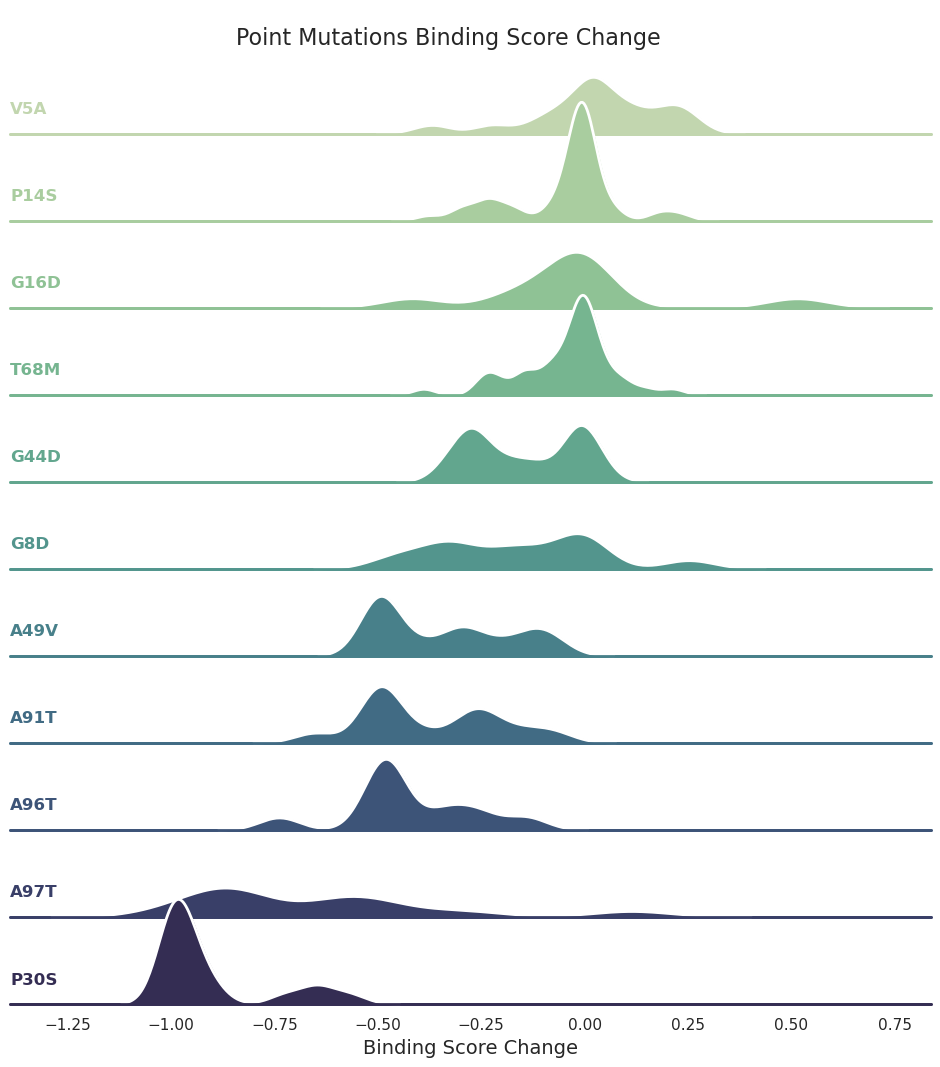

In [120]:
# Initialize the FacetGrid object
pal = sns.cubehelix_palette(n_colors=len(order), start=.5, rot=-0.75, light=0.8, dark=0.2)
# Create a palette dictionary mapping each sample to a color
# palette = sns.color_palette("tab20", n_colors=len(order))  # or your favorite palette
palette_dict = dict(zip(order, pal))

g = sns.FacetGrid(ridgedata_df, row="mutation", hue="mutation", aspect=10, height=1, palette=palette_dict, row_order=order)

# Draw the densities in a few steps
g.map(sns.kdeplot, "dscore",
      bw_adjust=0.5, clip_on=False,
      fill=True, alpha=1, linewidth=1, warn_singular=False)

# Add a white line at the bottom of each plot
g.map(plt.axhline, y=0, lw=2, clip_on=False)
# g.map(plt.axvspan(-0.2, 0.2, color='gray', alpha=0.15))

g.map(sns.kdeplot, "dscore", clip_on=False, color="white", lw=2, bw_adjust=0.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "dscore")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.3)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[],ylabel="")
g.set_xlabels("Binding Score Change", fontsize=14) 
g.despine(bottom=True, left=True)

plt.suptitle("Point Mutations Binding Score Change", fontsize=16, y=0.95)  # adjust y as needed

In [67]:
hotspotmut2 = []
neutralmut2 = []


for ref in list(singlemuts2.keys()):
    for var in list(singlemuts2[ref]):
        # print(hamming_distance(ref,var))
        scores = [rep2_df[rep2_df['aa_sequence'] == ref]['normalized_score_lib'].values[0], rep2_df[rep2_df['aa_sequence'] == var]['normalized_score_lib'].values[0]]
        scoredif = abs(scores[0]-scores[1])
        if scoredif > 0.7:
            print(f"sequence {ref} with score {scores[0]} has single mutant {var} with score {scores[1]}")
            for i, (aa1, aa2) in enumerate(zip(ref, var)):
                if aa1 != aa2:
                    pointmut = (i+1, aa1, aa2)
                    hotspotmut2.append(pointmut)
                    print(f"point mutation is {aa1}{i+1}{aa2}")
        if scoredif < 0.02:
            print(f"sequence {ref} with score {scores[0]} has single mutant {var} with score {scores[1]}")
            for i, (aa1, aa2) in enumerate(zip(ref, var)):
                if aa1 != aa2:
                    pointmut = (i+1, aa1, aa2)
                    neutralmut2.append(pointmut)
                    print(f"point mutation is {aa1}{i+1}{aa2}")

print(hotspotmut2[:10])
print(len(hotspotmut2))
print(neutralmut2[:10])
print(len(neutralmut2))


sequence QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGALVTVS with score 1.0 has single mutant QVQLAESAGGLVQPGGSLRLSCAASGRNVSMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGALVTVS with score 0.0
point mutation is P30S
sequence QVQLAESDGGLVQPGGSLCLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLVRNWYTYWGQGTLVTVS with score 1.0 has single mutant QVQLAESDGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLVRNWYTYWGQGTLVTVS with score 1.0
point mutation is C19R
sequence QVQLAESDGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 1.0 has single mutant QVQLAESDGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.982371
point mutation is P14S
sequence QVQLAESDGGLVQPGGSLRL

In [15]:
# take set of single mutants and associated point mutations (both neutral and hotspot) and graph as character bars

# reformat mutations list
hotspotmutform = [f"{aa1}{i}{aa2}" for i, aa1, aa2 in hotspotmut]
print(hotspotmutform[:4])

neutralmutform = [f"{aa1}{i}{aa2}" for i, aa1, aa2 in neutralmut]

hotspotmutform2 = [f"{aa1}{i}{aa2}" for i, aa1, aa2 in hotspotmut2]
print(hotspotmutform2[:4])

neutralmutform2 = [f"{aa1}{i}{aa2}" for i, aa1, aa2 in neutralmut2]

['A24D', 'G47R', 'R71H', 'R71H']
['P30S', 'R71H', 'A97T', 'P30S']


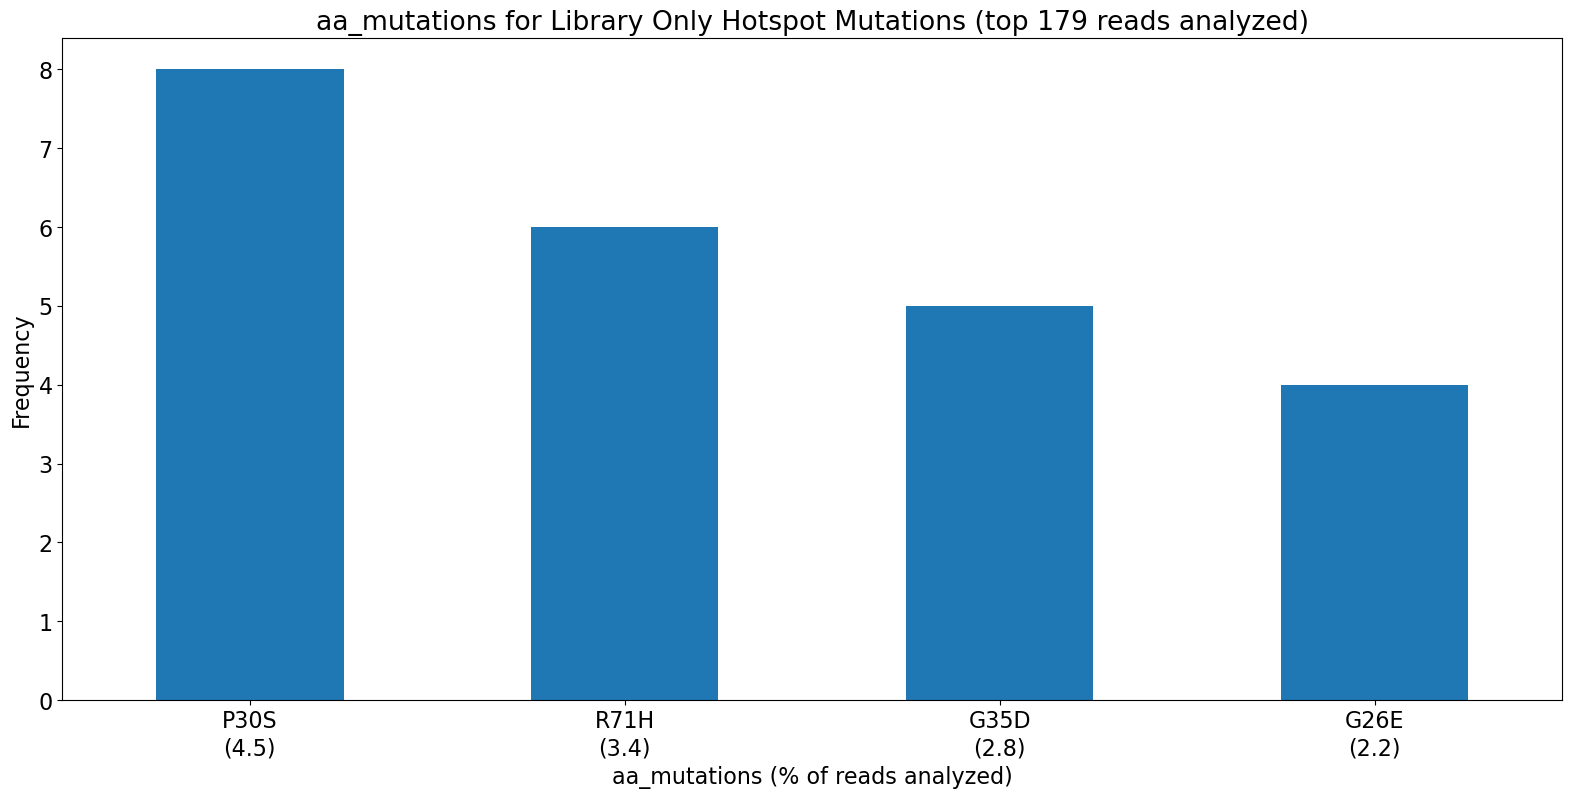

Histogram saved as ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_005/neutral_drift_library/libonly/plots/hotspot_mutation_freq_2pct.png


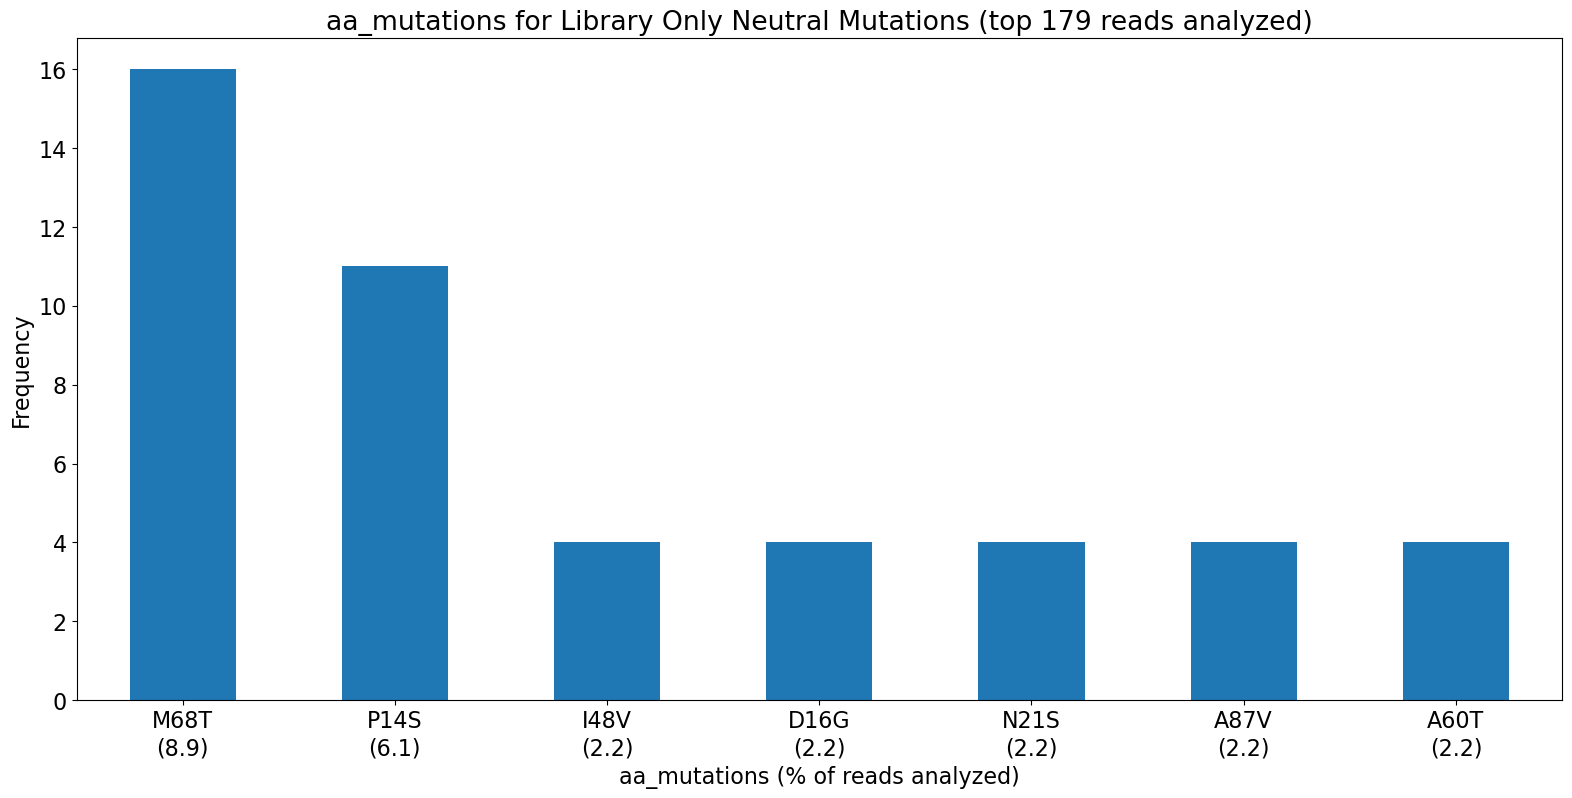

Histogram saved as ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_005/neutral_drift_library/libonly/plots/neutral_mutation_freq_2pct.png


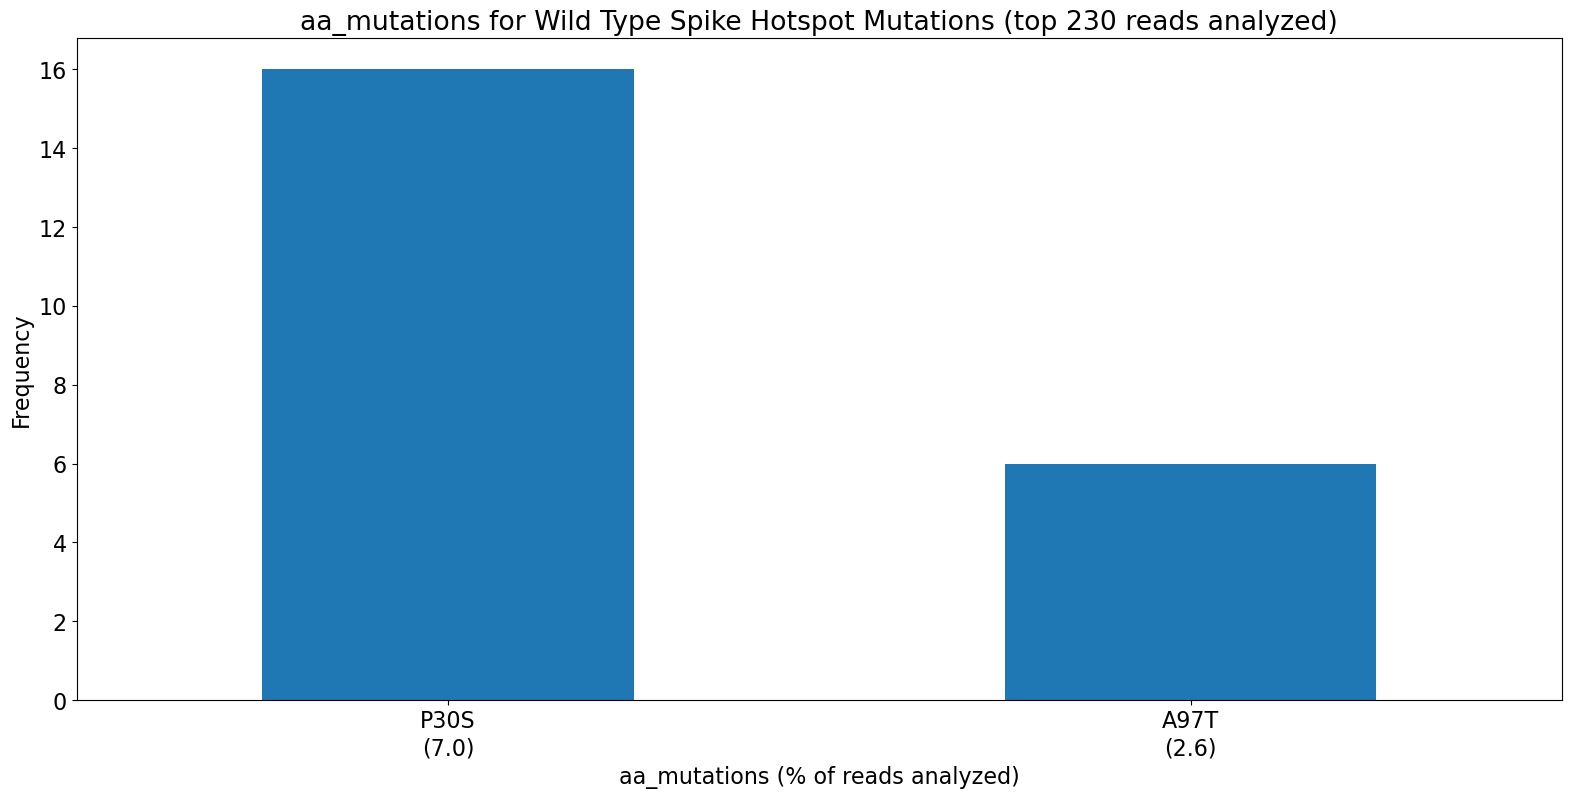

Histogram saved as ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_005/neutral_drift_library/wtspike/plots/hotspot_mutation_freq_2pct.png


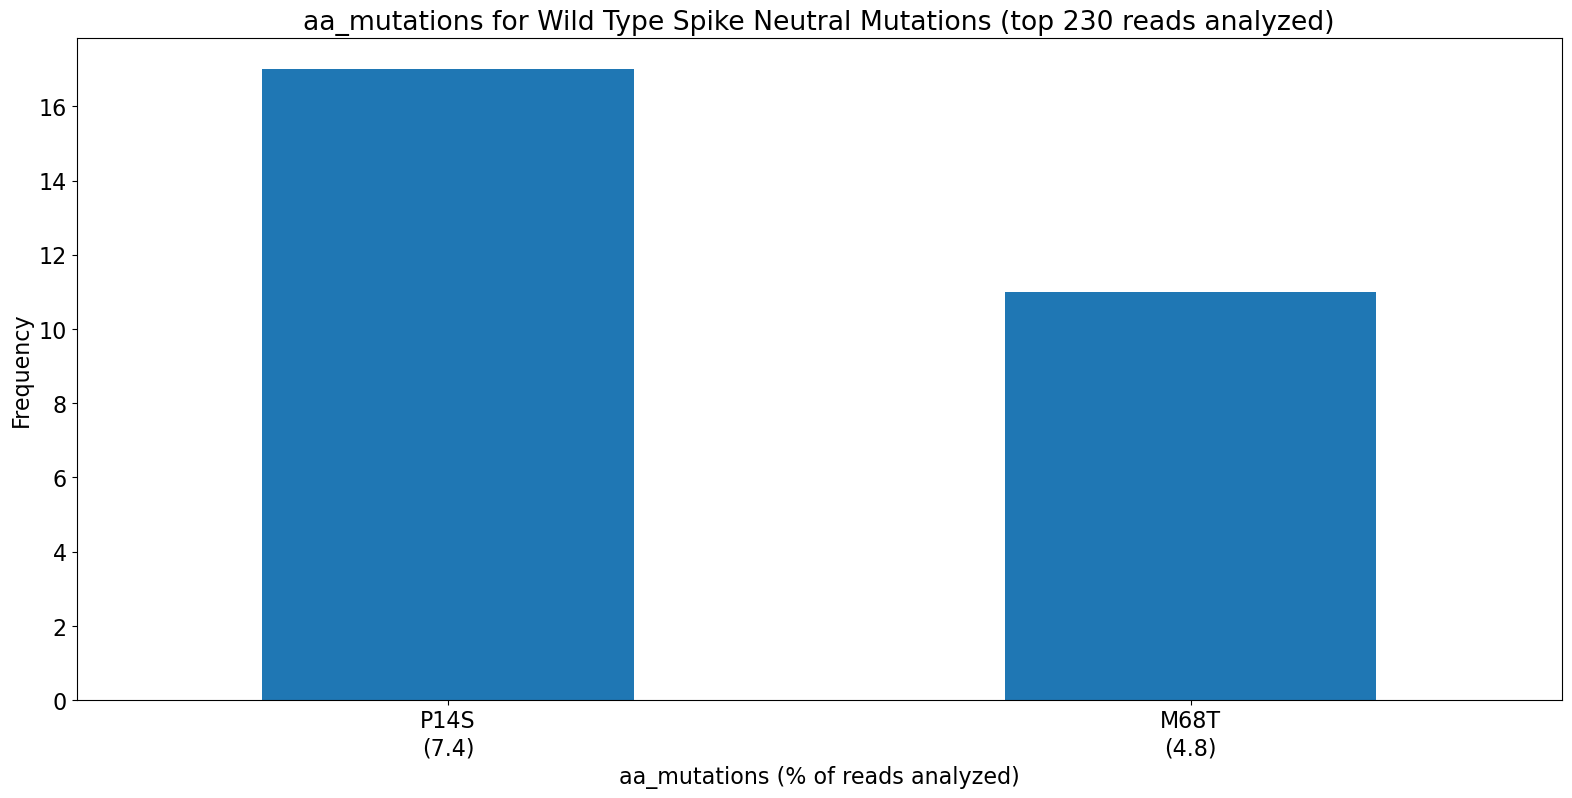

Histogram saved as ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_005/neutral_drift_library/wtspike/plots/neutral_mutation_freq_2pct.png


In [31]:
hotspotmutform_df = pd.DataFrame(hotspotmutform, columns = ['aa_mutations'])
neutralmutform_df = pd.DataFrame(neutralmutform, columns = ['aa_mutations'])
hotspotmutform2_df = pd.DataFrame(hotspotmutform2, columns = ['aa_mutations'])
neutralmutform2_df = pd.DataFrame(neutralmutform2, columns = ['aa_mutations'])



pct_cut = 2
# pct_cut_weighted = 6
rep1_output_paths = [f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/libonly/plots/hotspot_mutation_freq_{pct_cut}pct.png',
                     f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/libonly/plots/neutral_mutation_freq_{pct_cut}pct.png']

rep2_output_paths = [f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/wtspike/plots/hotspot_mutation_freq_{pct_cut}pct.png',
                     f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/wtspike/plots/neutral_mutation_freq_{pct_cut}pct.png']

# output_path_weighted = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/mutation_figs/{sample_name}/{sample_name}_mutation_freq_weighted_readct{read_ct}_{pct_cut_weighted}pct.png'
freq_cutoff1 = (len(list(singlemuts.keys()))*(pct_cut/100))
freq_cutoff2 = (len(list(singlemuts2.keys()))*(pct_cut/100))
# freq_cutoff_weighted = (num_weighted_reads*(pct_cut_weighted/100))
try:
    char_hist_unweighted = character_bars(hotspotmutform_df, rep1_output_paths[0], freq_cutoff1, "Library Only Hotspot Mutations", len(list(singlemuts.keys())))
    # char_hist_weighted = character_bars(aa_mut_weight_flat_df, output_path_weighted, freq_cutoff_weighted, sample_name+' (weighted by read count)', num_weighted_reads)
except Exception as e:
    print(f"Error processing graph: {str(e)}")
    if str(e) == 'index 0 is out of bounds for axis 0 with size 0':
        print('frequency cutoff is too high!')

try:
    char_hist_unweighted = character_bars(neutralmutform_df, rep1_output_paths[1], freq_cutoff1, "Library Only Neutral Mutations", len(list(singlemuts.keys())))    
except Exception as e:
    print(f"Error processing graph: {str(e)}")
    if str(e) == 'index 0 is out of bounds for axis 0 with size 0':
        print('frequency cutoff is too high!')

try:
    char_hist_unweighted = character_bars(hotspotmutform2_df, rep2_output_paths[0], freq_cutoff2, "Wild Type Spike Hotspot Mutations", len(list(singlemuts2.keys())))
except Exception as e:
    print(f"Error processing graph: {str(e)}")
    if str(e) == 'index 0 is out of bounds for axis 0 with size 0':
        print('frequency cutoff is too high!')

try:
    char_hist_unweighted = character_bars(neutralmutform2_df, rep2_output_paths[1], freq_cutoff2, "Wild Type Spike Neutral Mutations", len(list(singlemuts2.keys())))
except Exception as e:
    print(f"Error processing graph: {str(e)}")
    if str(e) == 'index 0 is out of bounds for axis 0 with size 0':
        print('frequency cutoff is too high!')

In [17]:
# double check with sequences that are present in both replicates

hamming_pairwise_aa_common = []

singlemuts_common = {}
for i in range(len(common_seqs_list)):
    aaseq = common_seqs_list[i]
    singlemutlist = []
    # print(aaseq)
    for j in range(i+1, len(common_seqs_list)):
        seqcomp = common_seqs_list[j]
        if seqcomp != aaseq:
            hamming_pairwise_aa_common.append(hamming_distance(aaseq, seqcomp))
        if hamming_pairwise_aa_common[-1] == 1:
            singlemutlist.append(seqcomp)
            singlemuts_common[aaseq] = singlemutlist
# print(len(hamming_pairwise_aa))
# print(hamming_pairwise_aa.count(1))
print(list(singlemuts_common.values())[:10])
print(len(list(singlemuts_common.keys())))

[['QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAVSIVGSLARNWYTYWGQGTLVTVS', 'QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQDLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAVSIVGSLARNWYTYWGQGTLVTVS', 'QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCATSIVGSLARNWYTYWGQGTLVTVS'], ['QVQLTESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYEDSIKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS', 'QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYEDSIKDRFMISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS'], ['QVQLAESGGGLVQSGGSLRLSCDASGRNVPMLSLDWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS', 'QVQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLDWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS'], ['QVQLVESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAVSIVGSLARNWYTYWGQGTLVTVS', 

In [56]:
# comprehensive list of pairs of single mutants organized by point mutation (wt spike library)

mutrec_common = []

for sequence in list(singlemuts_common.keys()):
    seqdist = hamming_distance(sequence, parent_aa_seq)
    for variant in list(singlemuts_common[sequence]):
        vardist = hamming_distance(variant, parent_aa_seq)
        scores_rep1 = [rep1_df[rep1_df['aa_sequence'] == sequence]['normalized_score_lib'].values[0], rep1_df[rep1_df['aa_sequence'] == variant]['normalized_score_lib'].values[0]]
        scores_rep2 = [rep2_df[rep2_df['aa_sequence'] == sequence]['normalized_score_lib'].values[0], rep2_df[rep2_df['aa_sequence'] == variant]['normalized_score_lib'].values[0]] 
        dist = seqdist if seqdist<vardist else vardist
        if seqdist<=vardist:
            dscore = np.mean([scores_rep1[1],scores_rep2[1]]) - np.mean([scores_rep1[0],scores_rep2[0]])
            for j, (aa1, aa2) in enumerate(zip(sequence, variant)):
                if aa1 != aa2:
                    pointmut = str(aa1+str(j+1)+aa2)
        else:
            dscore = np.mean([scores_rep1[0],scores_rep2[0]]) - np.mean([scores_rep1[1],scores_rep2[1]])
            for j, (aa1, aa2) in enumerate(zip(sequence, variant)):
                if aa1 != aa2:
                    pointmut = str(aa2+str(j+1)+aa1) #flips reference and mutation at position
                    
        mutrec_common.append({
            "sequence1": sequence,
            "sequence2": variant,
            "point mutation": pointmut,
            "wild type distance": dist,
            "score1": scores[0],
            "score2": scores[1],
            "delta score": dscore})

mutrec_common_df = pd.DataFrame(mutrec_common)

print(parent_aa_seq)

# print(mutrec_df)
print(mutrec_common_df[mutrec_common_df['point mutation'] == 'P30S'])

# group by point mutation

mut_common_dict = {}
noref_common_dict = {}

for mutation in mutrec_common_df['point mutation']:
    position = int(mutation[1:-1])-1
    # print(parent_aa_seq[position])
    if mutation[0] == parent_aa_seq[position]:
        mut_common_dict[mutation] = list(mutrec_common_df[mutrec_common_df['point mutation'] == mutation]['delta score'].values)
    else:
        noref_common_dict[mutation] = list(mutrec_common_df[mutrec_common_df['point mutation'] == mutation]['delta score'].values)

print(noref_common_dict)

QVQLVESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS
                                            sequence1  \
19  QVQLAESGGGLVQPGGSLRLSCAASGKNVSMLSLGWFRQAPGQGLE...   
23  QVQLAESGGGLVQPGDSLRLSCAASGRNVSMLSLGWFRQAPGQGLE...   
37  QVQLAESGGGLVQSGGSLRLSCAASGRNVSMLSLGWFRQAPGQGLE...   

                                            sequence2 point mutation  \
19  QVQLAESGGGLVQPGGSLRLSCAASGKNVPMLSLGWFRQAPGQGLE...           P30S   
23  QVQLAESGGGLVQPGDSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...           P30S   
37  QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...           P30S   

    wild type distance    score1  score2  delta score  
19                   2  0.046144     0.0    -0.906895  
23                   2  0.046144     0.0    -0.942317  
37                   3  0.046144     0.0    -0.738300  
{'V97T': [0.06397341706591098], 'A5T': [0.04670811014797627, 0.18995529848185422], 'T50V': [0.015555731350931024], 'E10R': [-0.1476225035

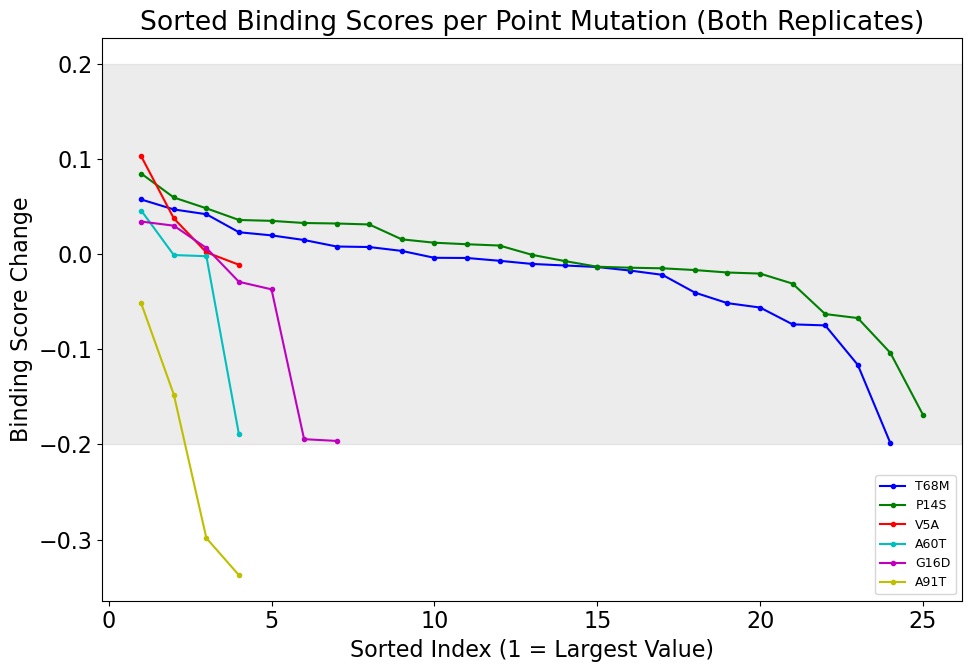

In [60]:
# now let's graph an ordered set of these point mutations and list scores

sorted_mut_common_dict = {k: sorted(v, reverse=True) for k, v in mut_common_dict.items()}
# print(sorted_mut_dict)
color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'orange', 'purple', 'pink', 'brown', 'olive', 'navy', 'teal']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=color_list)

plt.figure(figsize=(10, 7))

min_examples = 4

for label, values in sorted_mut_common_dict.items():
    # X values: indices (1, 2, 3, ..., length of list)
    x = range(1, len(values)+1)
    if len(x)>=min_examples:
        plt.plot(x, values, marker='o', markersize=3, label=label)

plt.axhspan(-0.2, 0.2, color='gray', alpha=0.15)
plt.xlabel('Sorted Index (1 = Largest Value)')
plt.ylabel('Binding Score Change')
plt.title('Sorted Binding Scores per Point Mutation (Both Replicates)')
plt.legend(fontsize=9,loc='lower right')
plt.tight_layout()
plt.show()


In [28]:
# score comparisons of single mutants (initial visual inspection looked very different)
# also need to identify the point mutation responsible

hotspotmut_common = []
neutralmut_common = []


for ref in list(singlemuts_common.keys()):
    for var in list(singlemuts_common[ref]):
        # print(hamming_distance(ref,var))
        scores1 = [rep1_df[rep1_df['aa_sequence'] == ref]['normalized_score_lib'].values[0], rep1_df[rep1_df['aa_sequence'] == var]['normalized_score_lib'].values[0]]
        scores2 = [rep2_df[rep2_df['aa_sequence'] == ref]['normalized_score_lib'].values[0], rep2_df[rep2_df['aa_sequence'] == var]['normalized_score_lib'].values[0]]
        # print(scores1,scores2)
        scoredif = np.mean([abs(scores1[0]-scores1[1]), abs(scores2[0]-scores2[1])])
        if scoredif > 0.7:
            print(f"sequence {ref} with score {scores[0]} has single mutant {var} with score {scores[1]}")
            for i, (aa1, aa2) in enumerate(zip(ref, var)):
                if aa1 != aa2:
                    pointmut = (i+1, aa1, aa2)
                    hotspotmut_common.append(pointmut)
                    print(f"point mutation is {aa1}{i+1}{aa2}")
        if scoredif < 0.02:
            print(f"sequence {ref} with score {scores[0]} has single mutant {var} with score {scores[1]}")
            for i, (aa1, aa2) in enumerate(zip(ref, var)):
                if aa1 != aa2:
                    pointmut = (i+1, aa1, aa2)
                    neutralmut_common.append(pointmut)
                    print(f"point mutation is {aa1}{i+1}{aa2}")

print(hotspotmut_common[:10])
print(len(hotspotmut_common))
print(neutralmut_common[:10])
print(len(neutralmut_common))

sequence QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLDWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.0 has single mutant QVQLAESGGGLVQSGGSLRLSCDASGRNVPMLSLDWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.0
point mutation is A23D
sequence QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVATIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.0 has single mutant QVQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLEGVAVIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.0
point mutation is T50V
sequence QVQLVESGGGLVQPGGSLRLSCAASGKNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.0 has single mutant QVQLAESGGGLVQPGGSLRLSCAASGKNVPMLSLGWFRQAPGQGLEGVAAIDYEGKTYYADSVKDRFTISRDNSKNTLYLQMNSLRAEDTAVYYCAASIVGSLARNWYTYWGQGTLVTVS with score 0.0
point mutation is V5A
sequence QVQLAESGGGLVQPGGSLRLSCAASG

In [29]:
# reformat mutations list
hotspotmutform_common = [f"{aa1}{i}{aa2}" for i, aa1, aa2 in hotspotmut_common]
print(hotspotmutform[:4])

neutralmutform_common = [f"{aa1}{i}{aa2}" for i, aa1, aa2 in neutralmut_common]

['A24D', 'G47R', 'R71H', 'R71H']


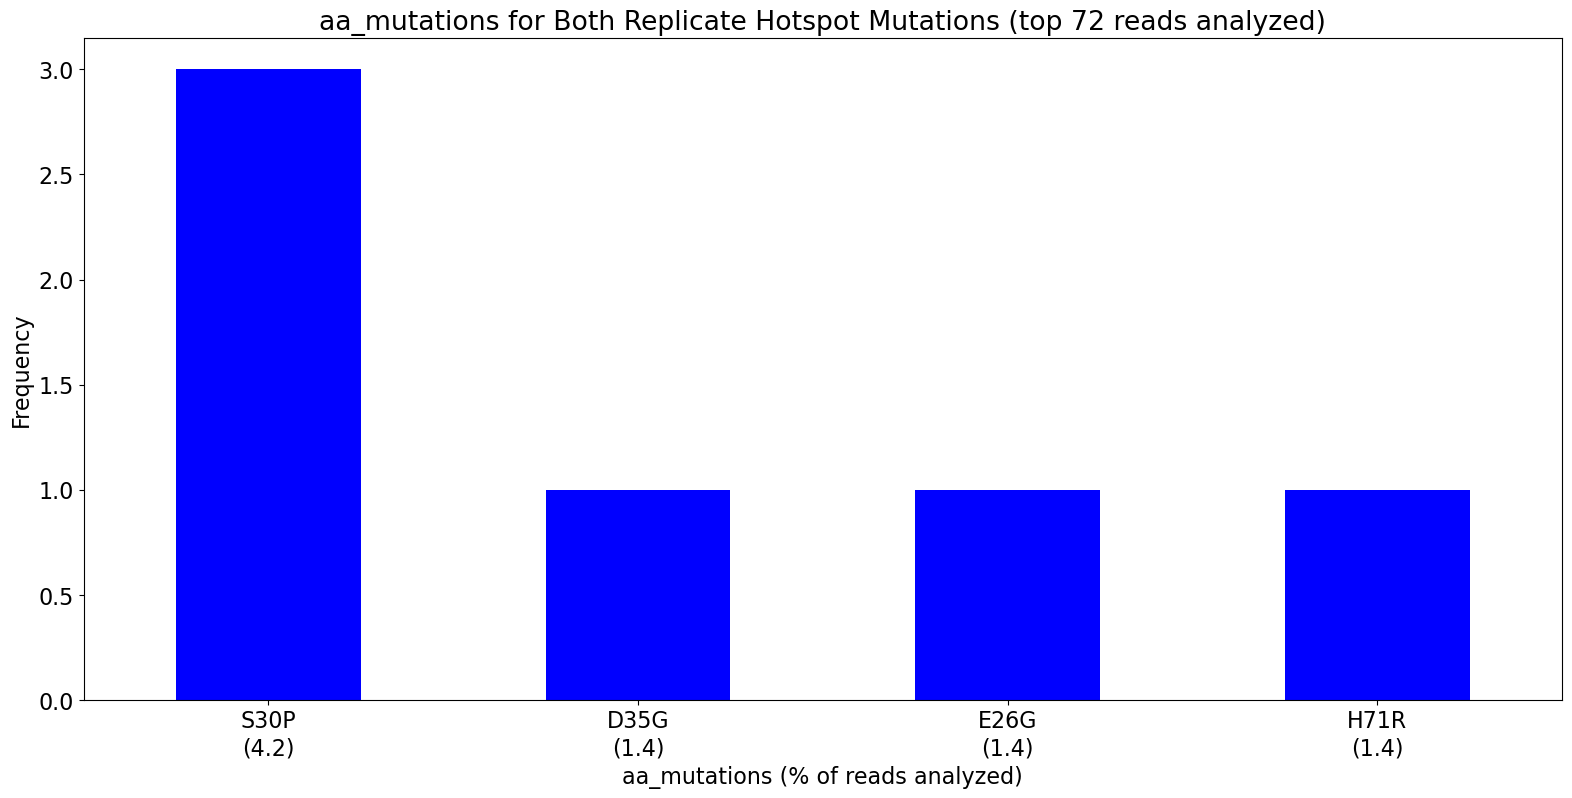

Histogram saved as ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_005/neutral_drift_library/plots/hotspot_mutation_freq_1pct.png


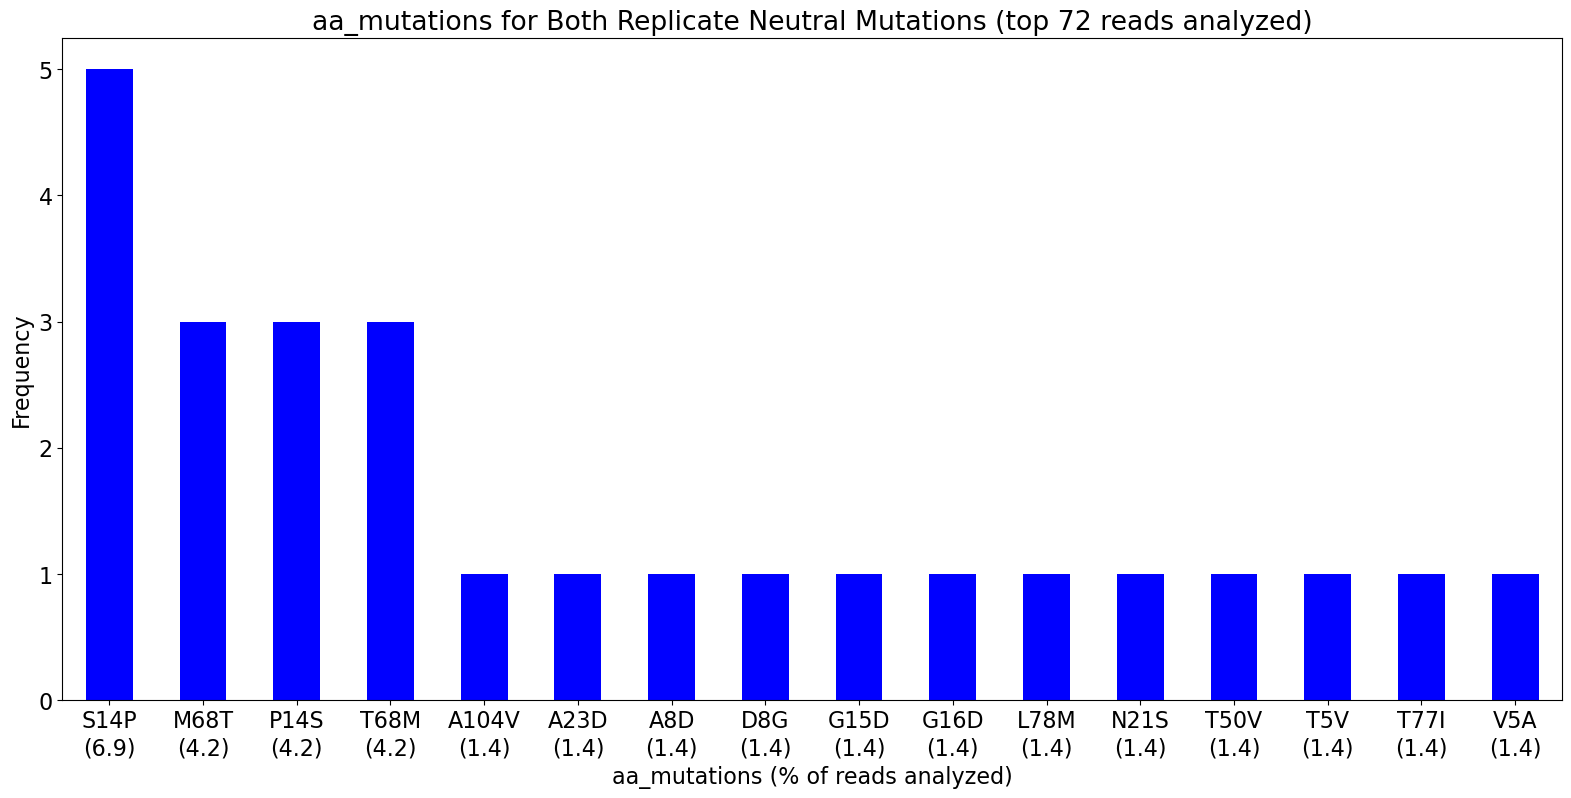

Histogram saved as ../../minibinders_orthorep_data/minibinders_orthorep_outputs/jh_005/neutral_drift_library/plots/neutral_mutation_freq_1pct.png


In [55]:
hotspotmutform_common_df = pd.DataFrame(hotspotmutform_common, columns = ['aa_mutations'])
neutralmutform_common_df = pd.DataFrame(neutralmutform_common, columns = ['aa_mutations'])



pct_cut = 1
# pct_cut_weighted = 6
common_output_paths = [f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/hotspot_mutation_freq_{pct_cut}pct.png',
                     f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/neutral_mutation_freq_{pct_cut}pct.png']


# output_path_weighted = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/mutation_figs/{sample_name}/{sample_name}_mutation_freq_weighted_readct{read_ct}_{pct_cut_weighted}pct.png'
freq_cutoff = (len(list(singlemuts_common.keys()))*(pct_cut/100))
# freq_cutoff_weighted = (num_weighted_reads*(pct_cut_weighted/100))
try:
    char_hist = character_bars(hotspotmutform_common_df, common_output_paths[0], freq_cutoff, "Both Replicate Hotspot Mutations", len(list(singlemuts_common.keys())))
    # char_hist_weighted = character_bars(aa_mut_weight_flat_df, output_path_weighted, freq_cutoff_weighted, sample_name+' (weighted by read count)', num_weighted_reads)
except Exception as e:
    print(f"Error processing graph: {str(e)}")
    if str(e) == 'index 0 is out of bounds for axis 0 with size 0':
        print('frequency cutoff is too high!')

try:
    char_hist = character_bars(neutralmutform_common_df, common_output_paths[1], freq_cutoff, "Both Replicate Neutral Mutations", len(list(singlemuts_common.keys())))
    # char_hist_weighted = character_bars(aa_mut_weight_flat_df, output_path_weighted, freq_cutoff_weighted, sample_name+' (weighted by read count)', num_weighted_reads)
except Exception as e:
    print(f"Error processing graph: {str(e)}")
    if str(e) == 'index 0 is out of bounds for axis 0 with size 0':
        print('frequency cutoff is too high!')

In [21]:
# P30S is the most interesting case (let's filter for all sequences that contain either residue at that site but can have any residue at the other sites

p30s_filtered_aaseq1 = rep1_df[rep1_df['aa_sequence'].str[29].isin(['P','S'])].copy()

print(len(p30s_filtered_aaseq1))
p30s_filtered_aaseq1.head()

729


,aa_sequence,dna_sequence,dna_mutations,aa_mutations,number_dna_mutations,number_aa_mutations,bin_1,bin_2,bin_3,normalized_score_lib,normalized_score_spike,predicted_category
0,QIQLAESGGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPDQGLE...,['CAGATCCAACTGGCCGAGAGCGGTGGGGGACTGGTGCAGCCAGG...,"[""['G4A', 'T14C', 'A54G', 'T87A', 'G125A', 'T1...","['V2I', 'V5A', 'G42D', 'A60T', 'S70I', 'A91T']",[11],6,0.000000,0.590514,0.409486,0.704743,0.704743,WT-like
1,QIQLAESGGGLVQSGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGATCCAACTGGCCGAGAGCGGTGGGGGACTGGTGCAGTCAGG...,"[""['G4A', 'T14C', 'C40T', 'T87A', 'G114A', 'G1...","['V2I', 'V5A', 'P14S', 'A49T', 'T115S']",[11],5,0.000000,0.602258,0.397742,0.698871,0.698871,WT-like
2,QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23C', 'T87A', 'C203T', 'A343G']"",...","['V5A', 'G8A', 'T68M', 'T115A']","[5, 6, 6, 7, 6, 7]",4,0.000000,0.011875,0.988125,0.994063,0.994063,WT-like
3,QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23C', 'T87A', 'C203T']"", ""['T14C'...","['V5A', 'G8A', 'T68M']","[4, 6, 6, 7, 7, 10, 6]",3,0.013074,0.051447,0.935479,0.961203,0.961203,WT-like
4,QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23C', 'T87A', 'C201T', 'C210T', '...","['V5A', 'G8A']","[7, 7, 5, 9]",2,0.000000,0.053415,0.946585,0.973292,0.973292,WT-like


In [22]:
p30s_filtered_aaseq2 = rep2_df[rep2_df['aa_sequence'].str[29].isin(['P','S'])].copy()

print(len(p30s_filtered_aaseq2))
p30s_filtered_aaseq2.head()

1605


,aa_sequence,dna_sequence,dna_mutations,aa_mutations,number_dna_mutations,number_aa_mutations,bin_1,bin_2,bin_3,normalized_score_lib,normalized_score_spike,predicted_category
2,QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23C', 'T87A', 'C203T', 'A343G']"",...","['V5A', 'G8A', 'T68M', 'T115A']","[5, 7, 6, 8, 7]",4,0.0,0.0,1.0,1.0,1.0,WT-like
4,QVQLAESAGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGCTGGGGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23C']"", ""['T14C', 'G23C', 'T87A']...","['V5A', 'G8A']","[2, 3, 4, 6, 7, 11, 5, 6]",2,0.0,0.0,1.0,1.0,1.0,WT-like
13,QVQLAESDGGLVQPGGSLCLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGATGGAGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23A', 'G27A', 'C55T', 'C66T', 'T8...","['V5A', 'G8D', 'R19C', 'A104V']","[11, 8, 10, 10, 10, 9, 10]",4,0.0,0.0,1.0,1.0,1.0,WT-like
19,QVQLAESDGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTTCAACTGGCCGAGAGCGATGGGGGACTGGTGCAGCCAGG...,"[""['C6T', 'T14C', 'G23A', 'T87A', 'C203T']"", ""...","['V5A', 'G8D', 'T68M']","[5, 9, 9, 4, 7, 8, 8, 7, 10, 6]",3,0.0,0.0,1.0,1.0,1.0,WT-like
23,QVQLAESDGGLVQPGGSLRLSCAASGRNVPMLSLGWFRQAPGQGLE...,['CAGGTCCAACTGGCCGAGAGCGATGGGGGACTGGTGCAGCCAGG...,"[""['T14C', 'G23A', 'T87A', 'C177T', 'G261A', '...","['V5A', 'G8D', 'A104V']","[7, 10, 8, 10, 10, 11, 9, 9, 10, 8]",3,0.0,0.0,1.0,1.0,1.0,WT-like


In [23]:
nop30s_aaseq1 = rep1_df[~rep1_df['aa_sequence'].str[29].isin(['P','S'])].copy()

nop30s_aaseq2 = rep2_df[~rep2_df['aa_sequence'].str[29].isin(['P','S'])].copy()

print(nop30s_aaseq1)
print(nop30s_aaseq2)

                                           aa_sequence  \
57   QVQLAESGGGLVQPGGSLRLSCAASGRNVLMLSLGWFRQAPGQGLE...   
622  QVQLAESGGGLVQPGGSLRLSCVASGRNITMLSLGWFRQASGQGLE...   
641  QVQLAESGGGLVQSGGSLCLSCAASGRNVTILSLGWFRQTPGQGLE...   
724  QVQLVESGRGLVQPGDSLRLSCAASGRNVTMLSLDWFRQAPGQGLE...   

                                          dna_sequence  \
57   ['CAGGTCCAACTGGCCGAGAGCGGTGGGGGACTGGTGCAGCCAGG...   
622  ['CAGGTCCAACTGGCCGAGAGCGGTGGGGGACTGGTGCAGCCAGG...   
641  ['CAGGTCCAACTGGCCGAGAGCGGTGGGGGACTGGTGCAGTCAGG...   
724  ['CAGGTCCAACTGGTCGAGAGCGGTAGGGGACTGGTACAGCCAGG...   

                                         dna_mutations  \
57   ["['T14C', 'T87A', 'C89T', 'G114A', 'G142A', '...   
622  ["['T14C', 'C68T', 'G85A', 'T87A', 'C88A', 'A9...   
641  ["['T14C', 'C40T', 'C55T', 'T69A', 'T87A', 'C8...   
724  ["['G25A', 'G36A', 'G47A', 'C66T', 'T87A', 'C8...   

                                          aa_mutations number_dna_mutations  \
57                     ['V5A', 'P30L', 'V48I', '

In [24]:
# lets do some binning of scores by position and by mutation (make a new dataframe organizing this)

amino_acids_dict = {
    'A': 'Alanine',
    'R': 'Arginine',
    'N': 'Asparagine',
    'D': 'Aspartic acid',
    'C': 'Cysteine',
    'Q': 'Glutamine',
    'E': 'Glutamic acid',
    'G': 'Glycine',
    'H': 'Histidine',
    'I': 'Isoleucine',
    'L': 'Leucine',
    'K': 'Lysine',
    'M': 'Methionine',
    'F': 'Phenylalanine',
    'P': 'Proline',
    'S': 'Serine',
    'T': 'Threonine',
    'W': 'Tryptophan',
    'Y': 'Tyrosine',
    'V': 'Valine'
}

mutscore_dict = {}
mut_scores = []

for pos, res in enumerate(parent_aa_seq):
    # print(f"position {pos+1}, residue {res}")
    for mut in list(amino_acids_dict.keys()):
        # singlemut = parent_aa_seq.replace(parent_aa_seq[pos], mut)
        singlemut = parent_aa_seq[:pos] + mut + parent_aa_seq[(pos+1):] if len(parent_aa_seq) > pos else parent_aa_seq
        # singlemut_list.append(singlemut)
        # print(singlemut)
        if singlemut != parent_aa_seq:
            try:
                mut_seq_df = rep1_df[rep1_df['aa_sequence'] == singlemut]
                mut_seq_df2 = rep2_df[rep2_df['aa_sequence'] == singlemut]
                if mut_seq_df.empty and mut_seq_df2.empty:
                    print(f"{res}{pos+1}{mut} not found") 
                elif mut_seq_df.empty:
                    mut_scores.append(mut_seq_df2['normalized_score_lib'].values[0]-wt_score.values[0])
                    mutation = str(res+str(pos+1)+mut)
                    mutscore_dict[mutation] = mut_scores[-1]
                elif mut_seq_df2.empty:
                    mut_scores.append(mut_seq_df['normalized_score_lib'].values[0]-wt_score.values[0])
                    mutation = str(res+str(pos+1)+mut)
                    mutscore_dict[mutation] = mut_scores[-1]
                else:
                    # print(mut_seq_df['aa_mutations'], mut_seq_df['normalized_score_lib'])
                    mut_scores.append([mut_seq_df['normalized_score_lib'].values[0]-wt_score.values[0],mut_seq_df2['normalized_score_lib'].values[0]-wt_score.values[0]])
                    mutation = str(res+str(pos+1)+mut)
                    mutscore_dict[mutation] = mut_scores[-1]
            except Exception as e:
                print("variant not found")
                print(f"error processing: {e}")

# for pos, res in enumerate(parent_aa_seq):
#     # print(f"position {pos+1}, residue {res}")
#     for mut in list(amino_acids_dict.keys()):
#         # singlemut = parent_aa_seq.replace(parent_aa_seq[pos], mut)
#         singlemut = parent_aa_seq[:pos] + mut + parent_aa_seq[(pos+1):] if len(parent_aa_seq) > pos else parent_aa_seq
#         # singlemut_list.append(singlemut)
#         # print(singlemut)
#         if singlemut != parent_aa_seq:
#             try:
#                 mut_seq_df = rep2_df[rep2_df['aa_sequence'] == singlemut]
#                 if mut_seq_df.empty:
#                     # print(f"{res}{pos+1}{mut} not found")
#                     score = 0
#                 else:
#                     # print(mut_seq_df['aa_mutations'], mut_seq_df['normalized_score_lib'])
#                     mut_scores.append(mut_seq_df['normalized_score_lib'].values[0]-wt_score.values[0])
#                     mutation = str(res+str(pos+1)+mut)
#                     mutscore_dict[mutation] = mut_scores[-1]
#             except Exception as e:
#                 print("variant not found")
#                 print(f"error processing: {e}")
        # if mut != res:
        #     for pos2 in range(len(list(amino_acids_dict.keys()))):
        #         if pos2 > pos:
        #             for mut2 in amino_acids_dict.keys():
        #                 doublemut = singlemut[:pos2] + mut2 + singlemut[(pos2+1):] if len(singlemut) > pos2 else singlemut
        #                 if doublemut != parent_aa_seq or doublemut != singlemut and mut2 != singlemut[pos2]:
        #                     try:
        #                         # print(doublemut)
        #                         # print("searching for mutant")
        #                         mut_seq_df = rep1_df[rep1_df['aa_sequence'] == doublemut]
        #                         if mut_seq_df.empty:
        #                             score = 0
        #                         else:
        #                             # print(mut_seq_df['aa_mutations'], mut_seq_df['normalized_score_lib'])
        #                             mut_scores.append(mut_seq_df['normalized_score_lib'].values[0]-wt_score.values[0])
        #                             mutations = str(res+str(pos+1)+mut+','+singlemut[pos2]+str(pos2+1)+mut2)
        #                             mutscore_dict[mutations] = mut_scores[-1]
        #                     except Exception as e:
        #                         print("variant not found")
        #                         print(f"error processing: {e}")  


# add score diff to mut_scores -- make as a dictionary
print(mutscore_dict)

Q1A not found
Q1R not found
Q1N not found
Q1D not found
Q1C not found
Q1E not found
Q1G not found
Q1H not found
Q1I not found
Q1L not found
Q1K not found
Q1M not found
Q1F not found
Q1P not found
Q1S not found
Q1T not found
Q1W not found
Q1Y not found
Q1V not found
V2A not found
V2R not found
V2N not found
V2D not found
V2C not found
V2Q not found
V2E not found
V2G not found
V2H not found
V2I not found
V2L not found
V2K not found
V2M not found
V2F not found
V2P not found
V2S not found
V2T not found
V2W not found
V2Y not found
Q3A not found
Q3N not found
Q3D not found
Q3C not found
Q3E not found
Q3G not found
Q3H not found
Q3I not found
Q3L not found
Q3K not found
Q3M not found
Q3F not found
Q3P not found
Q3S not found
Q3T not found
Q3W not found
Q3Y not found
Q3V not found
L4A not found
L4R not found
L4N not found
L4D not found
L4C not found
L4Q not found
L4E not found
L4G not found
L4H not found
L4I not found
L4K not found
L4M not found
L4F not found
L4P not found
L4S not found
L4T no

In [25]:
# ssm like plot (sparsely populated)

positions = list(range(1,len(parent_aa_seq)+1))
wtresidues = list(parent_aa_seq)

wt_df = pd.DataFrame({'position':positions, 'wtres':wtresidues})


rec = []
   
for mut, score in mutscore_dict.items():
    wt = mut[0]
    pos = int(mut[1:-1])
    mut_aa = mut[-1]
    rec.append({"position": pos, "wtres": wt, "mutres": mut_aa, "score": score})

mut_df = pd.DataFrame(rec)

rec_df = pd.merge(wt_df,mut_df, on=['position','wtres'], how='left')
rec_df = rec_df.fillna('')

def score_avg(score):
    if isinstance(score, list):
        return np.mean(score)
    return score

rec_df['avgscore'] = rec_df['score'].apply(score_avg)

rec_df['avgscore'] = rec_df['avgscore'].replace('',np.nan).infer_objects(copy=False)
rec_df['avgscore'] = pd.to_numeric(rec_df['avgscore'], errors='coerce')

# wt_seq = rec_df.drop_duplicates('position').sort_values('position')['wtres'].tolist()

print(rec_df[:6])
print(rec_df[110:])
# print(wt_seq)
print(wtresidues)

   position wtres mutres                                       score  avgscore
0         1     Q                                                          NaN
1         2     V                                                          NaN
2         3     Q      R                                    0.071511  0.071511
3         4     L                                                          NaN
4         5     V      A                                     0.06352  0.063520
5         5     V      T  [0.06861573542548982, 0.06396886802192003]  0.066292
     position wtres mutres     score  avgscore
110       108     Y                        NaN
111       109     T                        NaN
112       110     Y                        NaN
113       111     W      C -0.241633 -0.241633
114       112     G                        NaN
115       113     Q                        NaN
116       114     G      R -0.151151 -0.151151
117       115     T      A  0.040576  0.040576
118       116     L     

/tmp/ipykernel_2501/1864873733.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_df['avgscore'] = rec_df['avgscore'].replace('',np.nan).infer_objects(copy=False)


In [26]:
# Get only mutations with scores
positions = sorted(rec_df['position'].unique())
# print(positions)
wt_seq_map = rec_df.drop_duplicates('position').set_index('position')['wtres'].to_dict()
wt_pos_labels = [f"{pos}{wt_seq_map.get(pos, '')}" for pos in positions]
# print(wt_pos_labels)
all_aas = list('ACDEFGHIKLMNPQRSTVWY')

mut_df = rec_df[rec_df['mutres'].notna() & (rec_df['mutres'] != '') & rec_df['avgscore'].notna()]
# print(mut_df)

# Map from position number to its x-axis index (for correct col placement)
# pos2col = dict(zip(rec_df['position'].astype(int), wt_pos_labels))
pos2col = dict(zip(positions, wt_pos_labels))
# print(pos2col)

# Prepare the DataFrame to fill
heatmap_matrix = pd.DataFrame(index=all_aas, columns=wt_pos_labels, dtype=float)

# Fill in scores where known:
for _, row in mut_df.iterrows():
    pos = int(row['position'])
    if pos not in pos2col:
        continue
    col = pos2col[pos]
    heatmap_matrix.loc[row['mutres'], col] = row['avgscore']

print(heatmap_matrix)

   1Q  2V        3Q  4L        5V  6E  7S  8G  9G  10G  ...      111W  112G  \
A NaN NaN       NaN NaN  0.063520 NaN NaN NaN NaN  NaN  ...       NaN   NaN   
C NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ... -0.241633   NaN   
D NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ...       NaN   NaN   
E NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ...       NaN   NaN   
F NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ...       NaN   NaN   
G NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ...       NaN   NaN   
H NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ...       NaN   NaN   
I NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ...       NaN   NaN   
K NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ...       NaN   NaN   
L NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ...       NaN   NaN   
M NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  NaN  ...       NaN   NaN   
N NaN NaN       NaN NaN       NaN NaN NaN NaN NaN  N

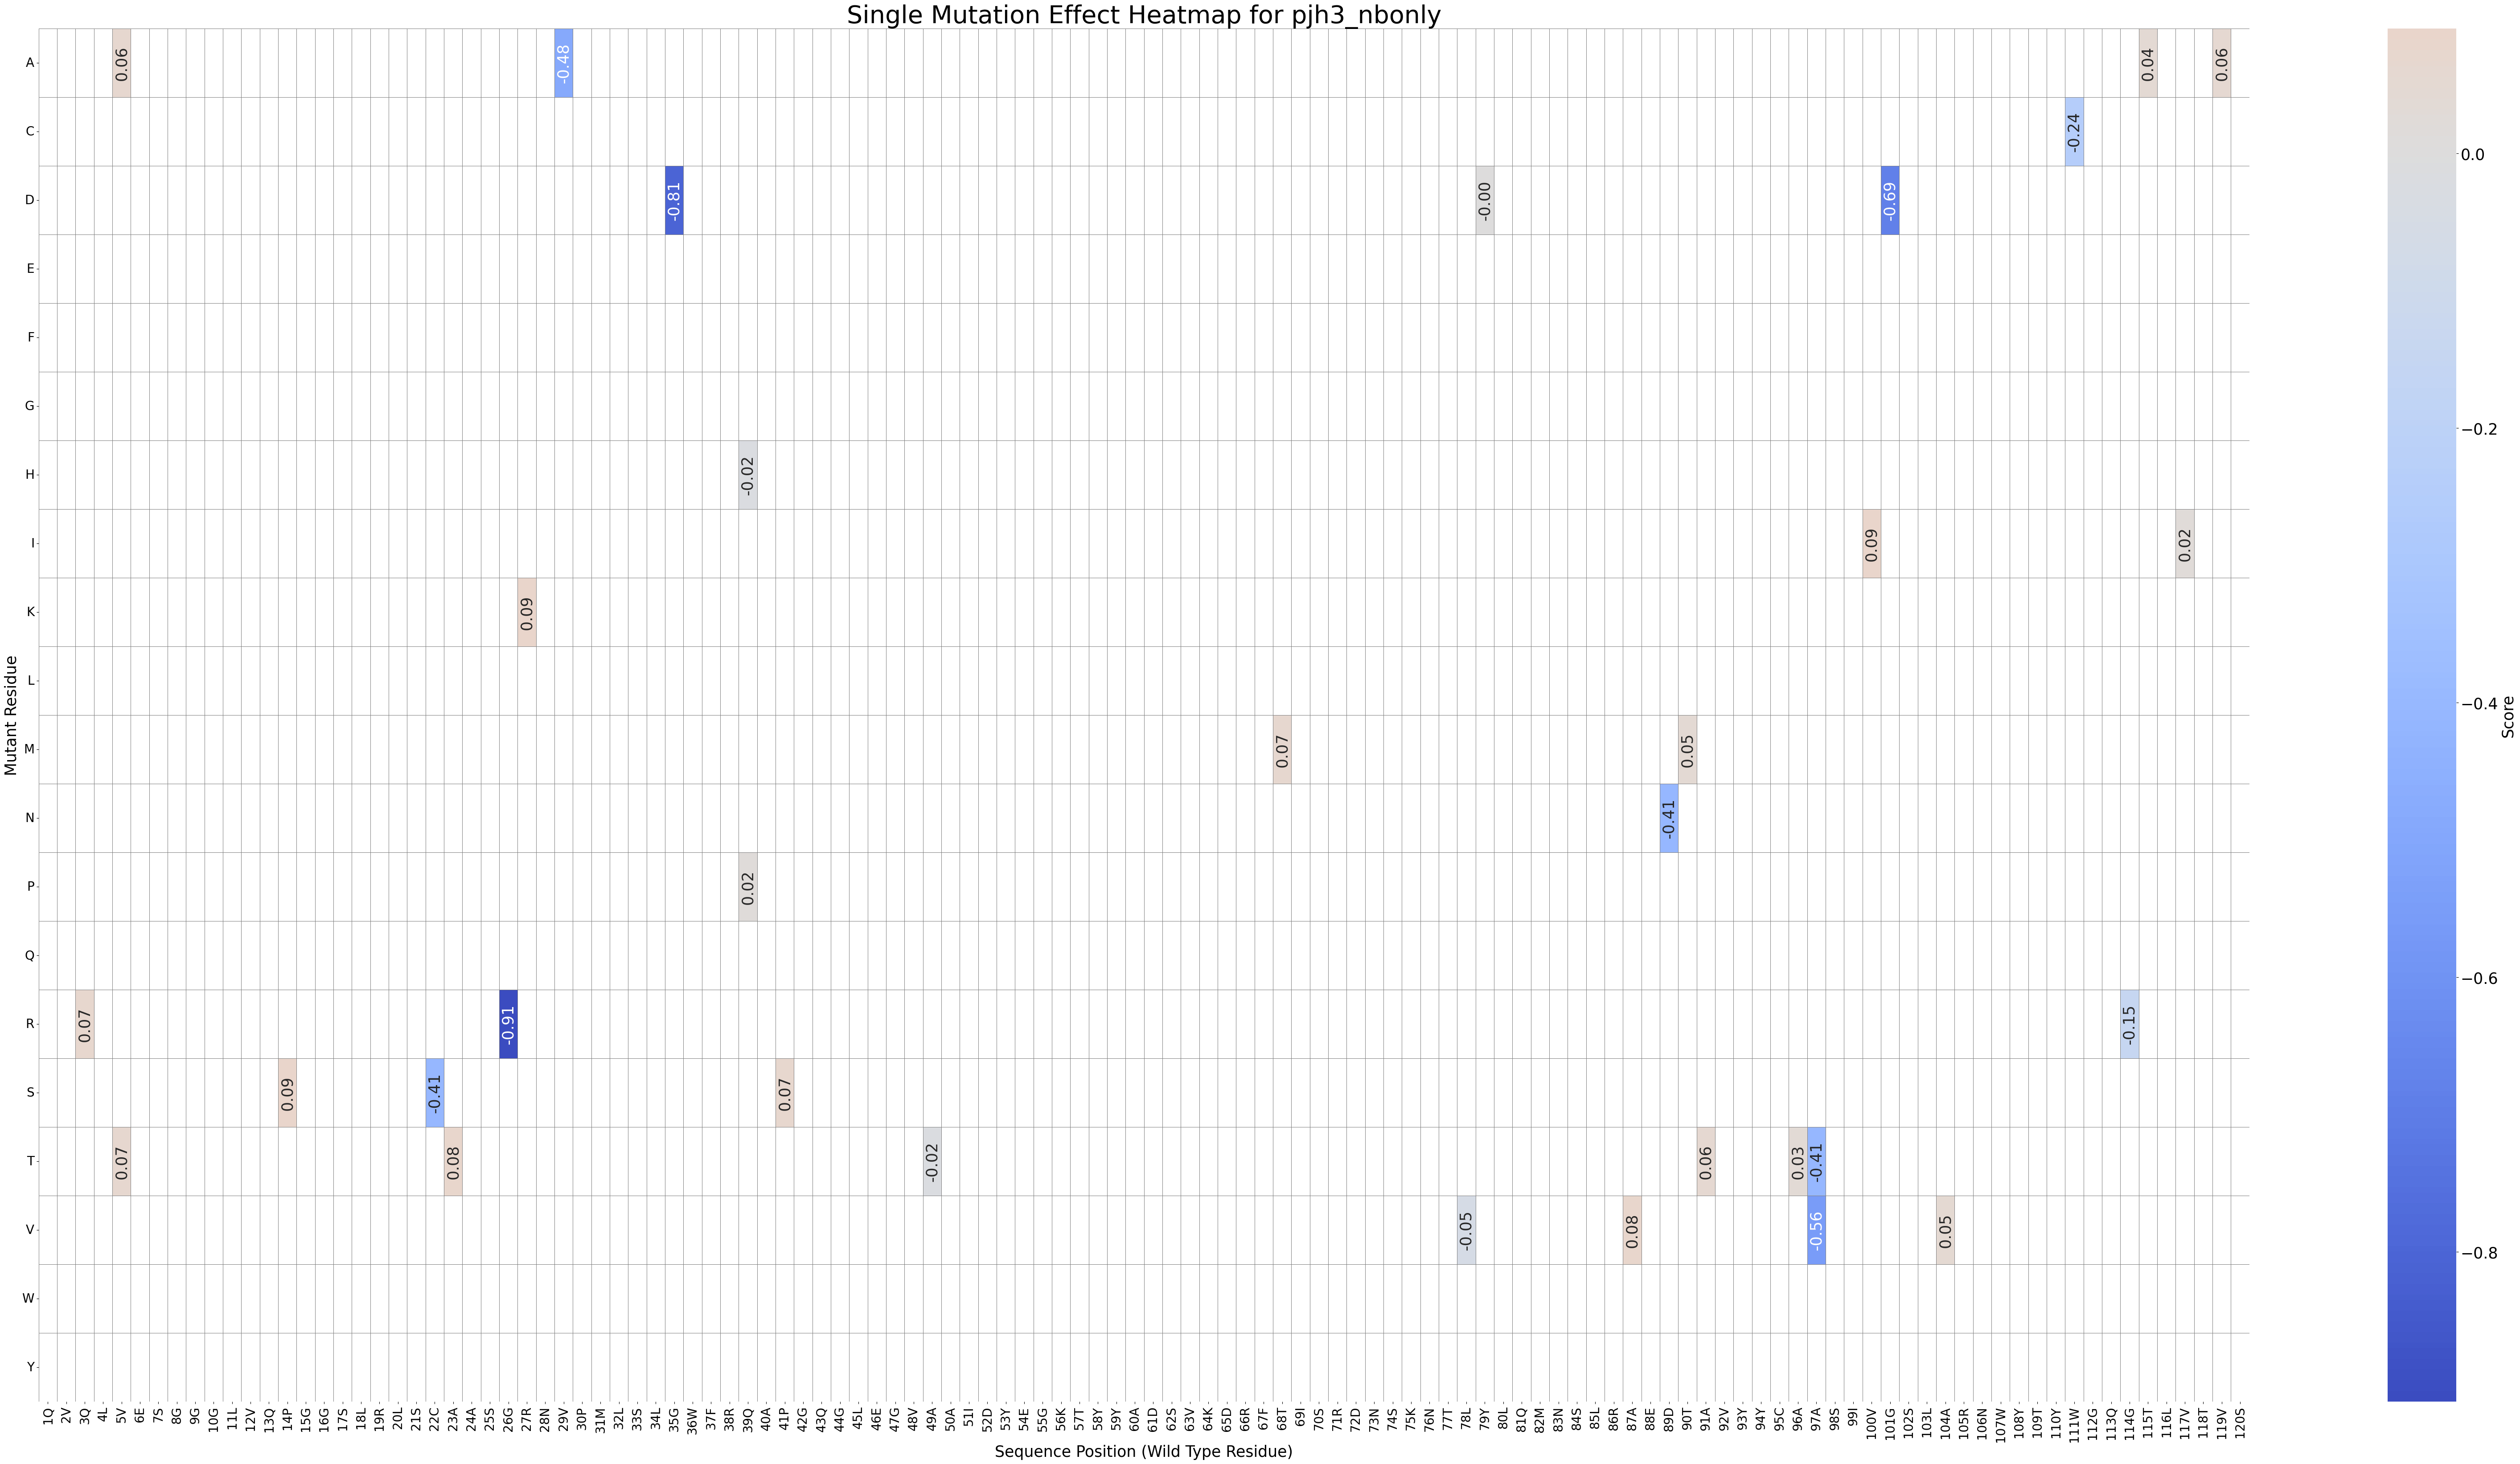

In [27]:
heatmap_outpath = f'../../minibinders_orthorep_data/minibinders_orthorep_outputs/{experiment_id}/neutral_drift_library/plots/1mut_heatmap.png'

plt.rcParams.update({
    'font.size': 25,
    # 'font.family': 'Arial'
})

plt.figure(figsize=(len(heatmap_matrix.columns)/1.5, 40))
ax = sns.heatmap(
    heatmap_matrix,
    annot=True, fmt=".2f",
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Score'},
    annot_kws={"fontsize":25,"rotation":90}
)
ax.set_xticklabels(heatmap_matrix.columns, rotation=90, fontsize=20)
ax.set_yticklabels(heatmap_matrix.index, rotation=0, fontsize=20)
plt.xlabel('Sequence Position (Wild Type Residue)')
plt.ylabel('Mutant Residue')
plt.title(f'Single Mutation Effect Heatmap for {fasta_name}', fontsize=40)
# plt.tight_layout()
plt.savefig(heatmap_outpath, format='png', dpi=500, bbox_inches='tight')
plt.show()